<a href="https://colab.research.google.com/github/Rehman-Cg7/AIML/blob/main/Task_Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rehmanahm","key":"67bd4ee1d9f61214d070d27ebef19ec4"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 171MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [4]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Counts dekho
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


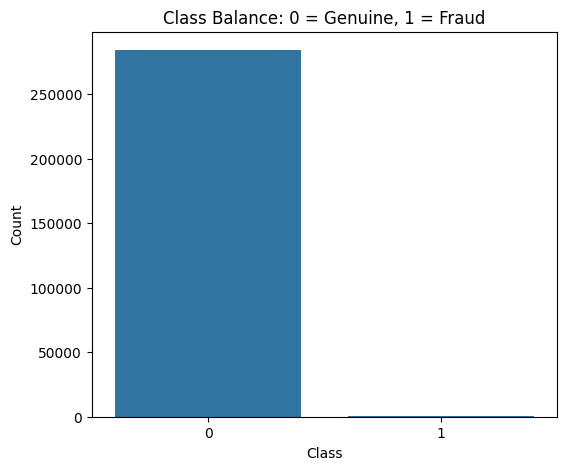

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.countplot(x='Class', data=df)
plt.title('Class Balance: 0 = Genuine, 1 = Fraud')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

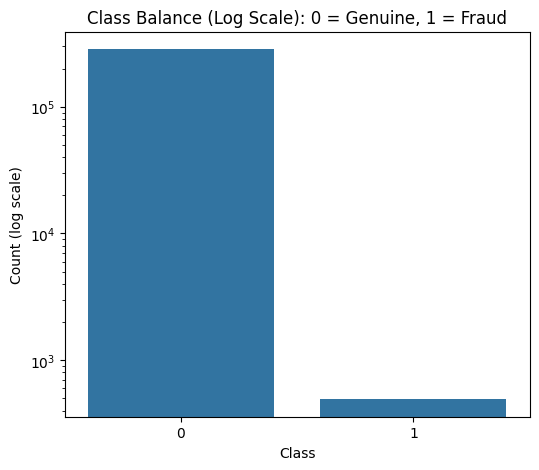

In [7]:
plt.figure(figsize=(6,5))
sns.countplot(x='Class', data=df)
plt.yscale('log')
plt.title('Class Balance (Log Scale): 0 = Genuine, 1 = Fraud')
plt.xlabel('Class')
plt.ylabel('Count (log scale)')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Features aur target alag karo
X = df.drop(columns=['Class'])
y = df['Class']

# Train-test split (stratify zaroori hai imbalanced data ke liye)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline model - bina kisi imbalance handling ke
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("=== BEFORE (Baseline - No Imbalance Handling) ===")
print(classification_report(y_test, y_pred_baseline))

=== BEFORE (Baseline - No Imbalance Handling) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
baseline_model = LogisticRegression(max_iter=2000)

In [10]:
weighted_model = LogisticRegression(max_iter=2000, class_weight='balanced')
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

print("=== AFTER (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_weighted))

=== AFTER (class_weight='balanced') ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# SMOTE sirf training data pe (test data ko chhuna nahi)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [12]:
smote_model = LogisticRegression(max_iter=2000)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

print("=== AFTER (SMOTE) ===")
print(classification_report(y_test, y_pred_smote))

=== AFTER (SMOTE) ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Why Accuracy Would Be Misleading Here

Only **0.17% of the transactions in this dataset are fraudulent** (492 fraud cases, with only 98 in the test set). The baseline model achieved **100% accuracy**, but it actually missed around **30% of the fraud cases**, with a **Recall of only 0.69**. This happened because the model performed extremely well on the majority class (genuine transactions), which made the overall accuracy appear perfect, even though its performance on the minority class (fraud) was poor.

That is why it was important to evaluate **Precision, Recall, and F1-score**. These metrics revealed that the baseline model was actually weak at detecting fraudulent transactions.

## Comparing Imbalance-Handling Techniques

**Class Weighting** increased Recall from **0.69 to 0.92**, but Precision dropped significantly from **0.84 to 0.06**. This means the model incorrectly classified many genuine transactions as fraud, resulting in a very high number of false alarms.

**SMOTE** also increased Recall to **0.91**, which was similar to Class Weighting. However, its Precision was **0.12**, which was better than Class Weighting. Therefore, **SMOTE appeared to be a more practical technique for this dataset**, as it provided high Recall while maintaining slightly better Precision.

This demonstrates that handling class imbalance always involves a **trade-off**. Increasing Recall can lead to lower Precision, and the best technique ultimately depends on the business objective—for example, whether it is more important to detect every possible fraud case or to minimize false alarms.


## Week 5 - Task: Handling Imbalanced Data (Credit Card Fraud Detection)

### Dataset
- 284,807 transactions | 492 fraud cases (0.17%) — extremely imbalanced

### Before vs After (Fraud class metrics)

| Approach          | Precision | Recall | F1-score |
|--------------------|-----------|--------|----------|
| Baseline (No Fix)  | 0.84      | 0.69   | 0.76     |
| Class Weighting    | 0.06      | 0.92   | 0.11     |
| SMOTE              | 0.12      | 0.91   | 0.21     |

### Key Learning
Accuracy was misleading (100%) despite the baseline model missing ~30% of
fraud cases. SMOTE gave the best balance between catching fraud (high
recall) and minimizing false alarms (better precision than class weighting).